In [2]:
import numpy as np
from matplotlib import pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from torchvision import datasets

torch.manual_seed(2382)
np.random.seed(2382)

### NOTE: If you are running this in JupyterLab, you will have to do the following:
+ Uncomment the "pip install" lines below and then run this cell. 
   This will install CPU-only PyTorch in your JupyterLab environment.
+ Wait until the installation completes.
+ Comment out the lines again, to prevent unnecessary re-installs.
+ Restart your kernel (Kernel>Restart kernel and clear output of all cells...)

In [ ]:
# %pip install --upgrade pip
# %pip install --extra-index-url https://download.pytorch.org/whl/cpu torch

# 0. Load the data

In [3]:
train_raw = datasets.MNIST(root='data', train=True, download=True)
test_raw = datasets.MNIST(root='data', train=False, download=True)

Xtrain = train_raw.data.float().unsqueeze(1) / 255.0
ytrain = train_raw.targets
Xtest = test_raw.data.float().unsqueeze(1) / 255.0
ytest = test_raw.targets

100.0%
100.0%
100.0%
100.0%


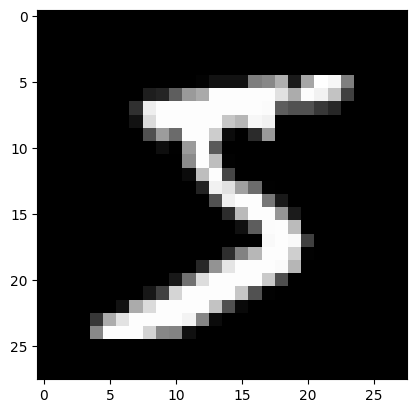

tensor(5)


In [7]:
Xtrain[0].shape
# plot the first image of the training dataset
plt.imshow(Xtrain[0].squeeze(), cmap='gray')
plt.show()

print(ytrain[0])

# 1. Data normalization, tensor preparation, and DataLoaders

In [11]:
full_train_dataset = TensorDataset(Xtrain, ytrain)
test_dataset = TensorDataset(Xtest, ytest)

n_valid = 10000
n_train = len(full_train_dataset) - n_valid
train_dataset, valid_dataset = random_split(
    full_train_dataset,
    [n_train, n_valid],
    generator=torch.Generator().manual_seed(2382)
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# 2. Convolutional neural network

In [12]:
model = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(16, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(32 * 7 * 7, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)

In [13]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 3. Train the model

In [14]:
history = {"epoch": [], "loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}

for epoch in range(5):
    model.train()
    train_loss_total = 0.0
    train_correct = 0
    train_count = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()

        train_loss_total += loss.item() * xb.size(0)
        train_correct += (logits.argmax(dim=1) == yb).sum().item()
        train_count += xb.size(0)

    model.eval()
    valid_loss_total = 0.0
    valid_correct = 0
    valid_count = 0
    with torch.no_grad():
        for xb, yb in valid_loader:
            logits = model(xb)
            loss = loss_fn(logits, yb)
            valid_loss_total += loss.item() * xb.size(0)
            valid_correct += (logits.argmax(dim=1) == yb).sum().item()
            valid_count += xb.size(0)

    history['epoch'].append(epoch)
    history['loss'].append(train_loss_total / train_count)
    history['val_loss'].append(valid_loss_total / valid_count)
    history['accuracy'].append(train_correct / train_count)
    history['val_accuracy'].append(valid_correct / valid_count)

    print(f"Epoch {epoch}: loss={history['loss'][-1]:.4f}, val_loss={history['val_loss'][-1]:.4f}, "
          f"accuracy={history['accuracy'][-1]:.4f}, val_accuracy={history['val_accuracy'][-1]:.4f}")

Epoch 0: loss=0.3981, val_loss=0.1286, accuracy=0.8841, val_accuracy=0.9637
Epoch 1: loss=0.0908, val_loss=0.0831, accuracy=0.9734, val_accuracy=0.9753
Epoch 2: loss=0.0647, val_loss=0.0664, accuracy=0.9807, val_accuracy=0.9804
Epoch 3: loss=0.0513, val_loss=0.0654, accuracy=0.9835, val_accuracy=0.9815
Epoch 4: loss=0.0436, val_loss=0.0577, accuracy=0.9868, val_accuracy=0.9833


### Evolution of the model during training

Text(0.5, 0, 'epochs')

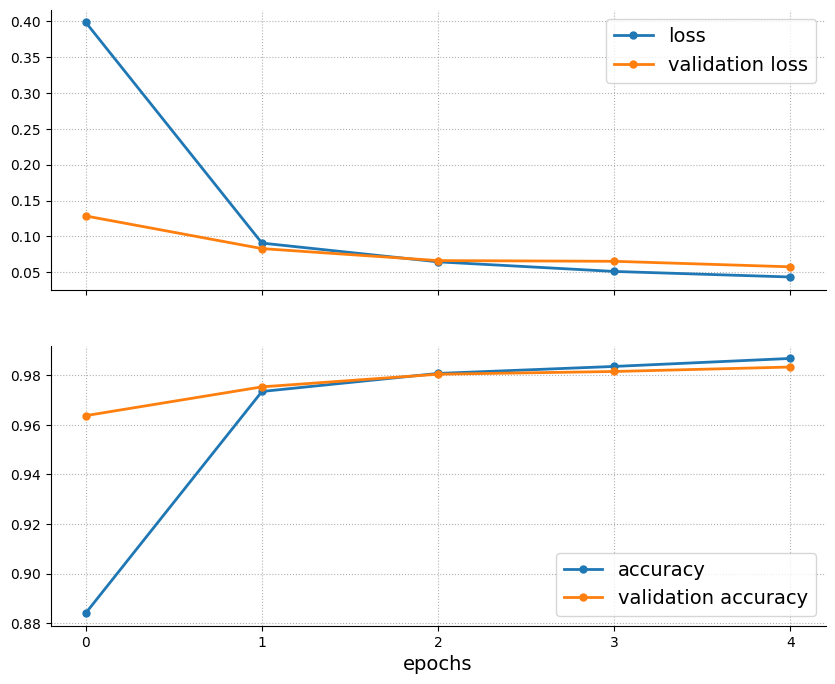

In [15]:
fig, axs = plt.subplots(figsize=(10,8), nrows=2, sharex=True)

ax = axs[0]
ax.plot(history['epoch'], history['loss'], '.-', linewidth=2, markersize=10, label='loss')
ax.plot(history['epoch'], history['val_loss'], '.-', linewidth=2, markersize=10, label='validation loss')
ax.grid(linestyle=':')
ax.legend(fontsize=14)
ax.spines[['top','right']].set_visible(False)

ax = axs[1]
ax.plot(history['epoch'], history['accuracy'], '.-', linewidth=2, markersize=10, label='accuracy')
ax.plot(history['epoch'], history['val_accuracy'], '.-', linewidth=2, markersize=10, label='validation accuracy')
ax.grid(linestyle=':')
ax.legend(fontsize=14)
ax.spines[['top','right']].set_visible(False)
ax.set_xticks(history['epoch'])
ax.set_xlabel('epochs', fontsize=14)

# 4. Evaluate on the test data

In [16]:
test_loss_total = 0.0
test_correct = 0
test_count = 0

model.eval()
with torch.no_grad():
    for xb, yb in test_loader:
        logits = model(xb)
        loss = loss_fn(logits, yb)
        test_loss_total += loss.item() * xb.size(0)
        test_correct += (logits.argmax(dim=1) == yb).sum().item()
        test_count += xb.size(0)

testresult = {
    'loss': test_loss_total / test_count,
    'accuracy': test_correct / test_count
}
testresult

{'loss': 0.04192257530046627, 'accuracy': 0.9859}